In [2]:
import seaborn as sns
from sklearn.model_selection import train_test_split

## import dataset from sns "Titanic"

In [3]:
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
feature = ['pclass','sex','fare','embarked','age']
target=['survived']

In [5]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
titanic.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## Handel_Missing_value

In [7]:
from sklearn.impute import SimpleImputer

### categorial_missing_value

In [8]:
imp_cate = SimpleImputer(strategy = "most_frequent")
titanic[['embarked']] = imp_cate.fit_transform(titanic[["embarked"]])

### numerical_missing_value

In [9]:
imp_numerical = SimpleImputer(strategy="median")
titanic[["age"]]= imp_numerical.fit_transform(titanic[['age']])

## Label Encoding

In [10]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
ls = LabelEncoder()
titanic["sex"]= ls.fit_transform(titanic["sex"])
titanic["embarked"]=ls.fit_transform(titanic["embarked"])

In [13]:
X = titanic[feature]
y = titanic[target]

## Train_test_split

In [14]:
X_train ,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## train Decision Tree Model

In [15]:
from sklearn.tree import DecisionTreeClassifier

In [16]:
model = DecisionTreeClassifier()
model.fit(X_train,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [17]:
Y_predict = model.predict(X_test)

### acuracy check 

In [18]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [19]:
print("acc",accuracy_score(Y_test,Y_predict))
print("pre",precision_score(Y_test,Y_predict))
print("recall",recall_score(Y_test,Y_predict))
print("f1",f1_score(Y_test,Y_predict))

acc 0.770949720670391
pre 0.7037037037037037
recall 0.7702702702702703
f1 0.7354838709677419


## DROW Decison Tree

In [20]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

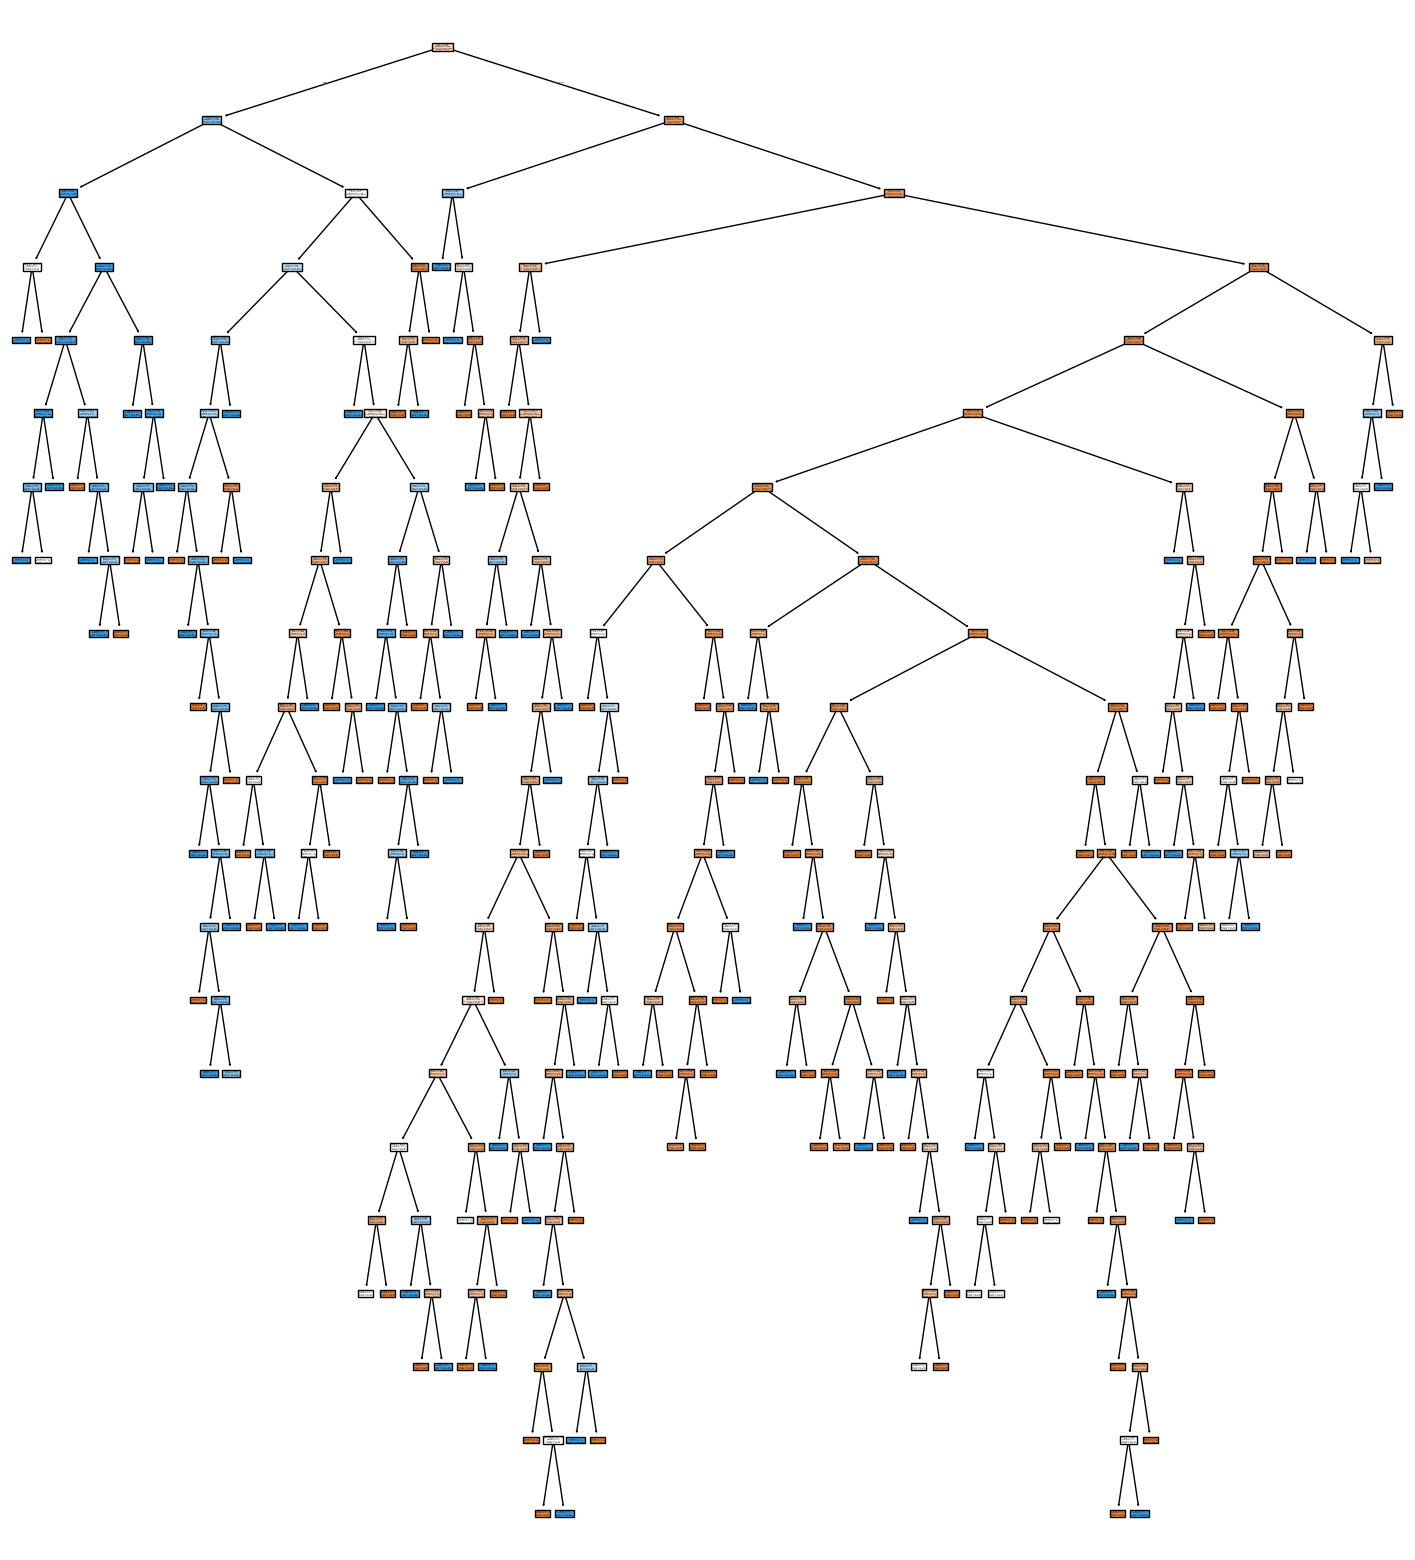

In [21]:
plt.figure(figsize=(18,20))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","survived"],
    filled=True,
     # max_depth =2
)
plt.show()

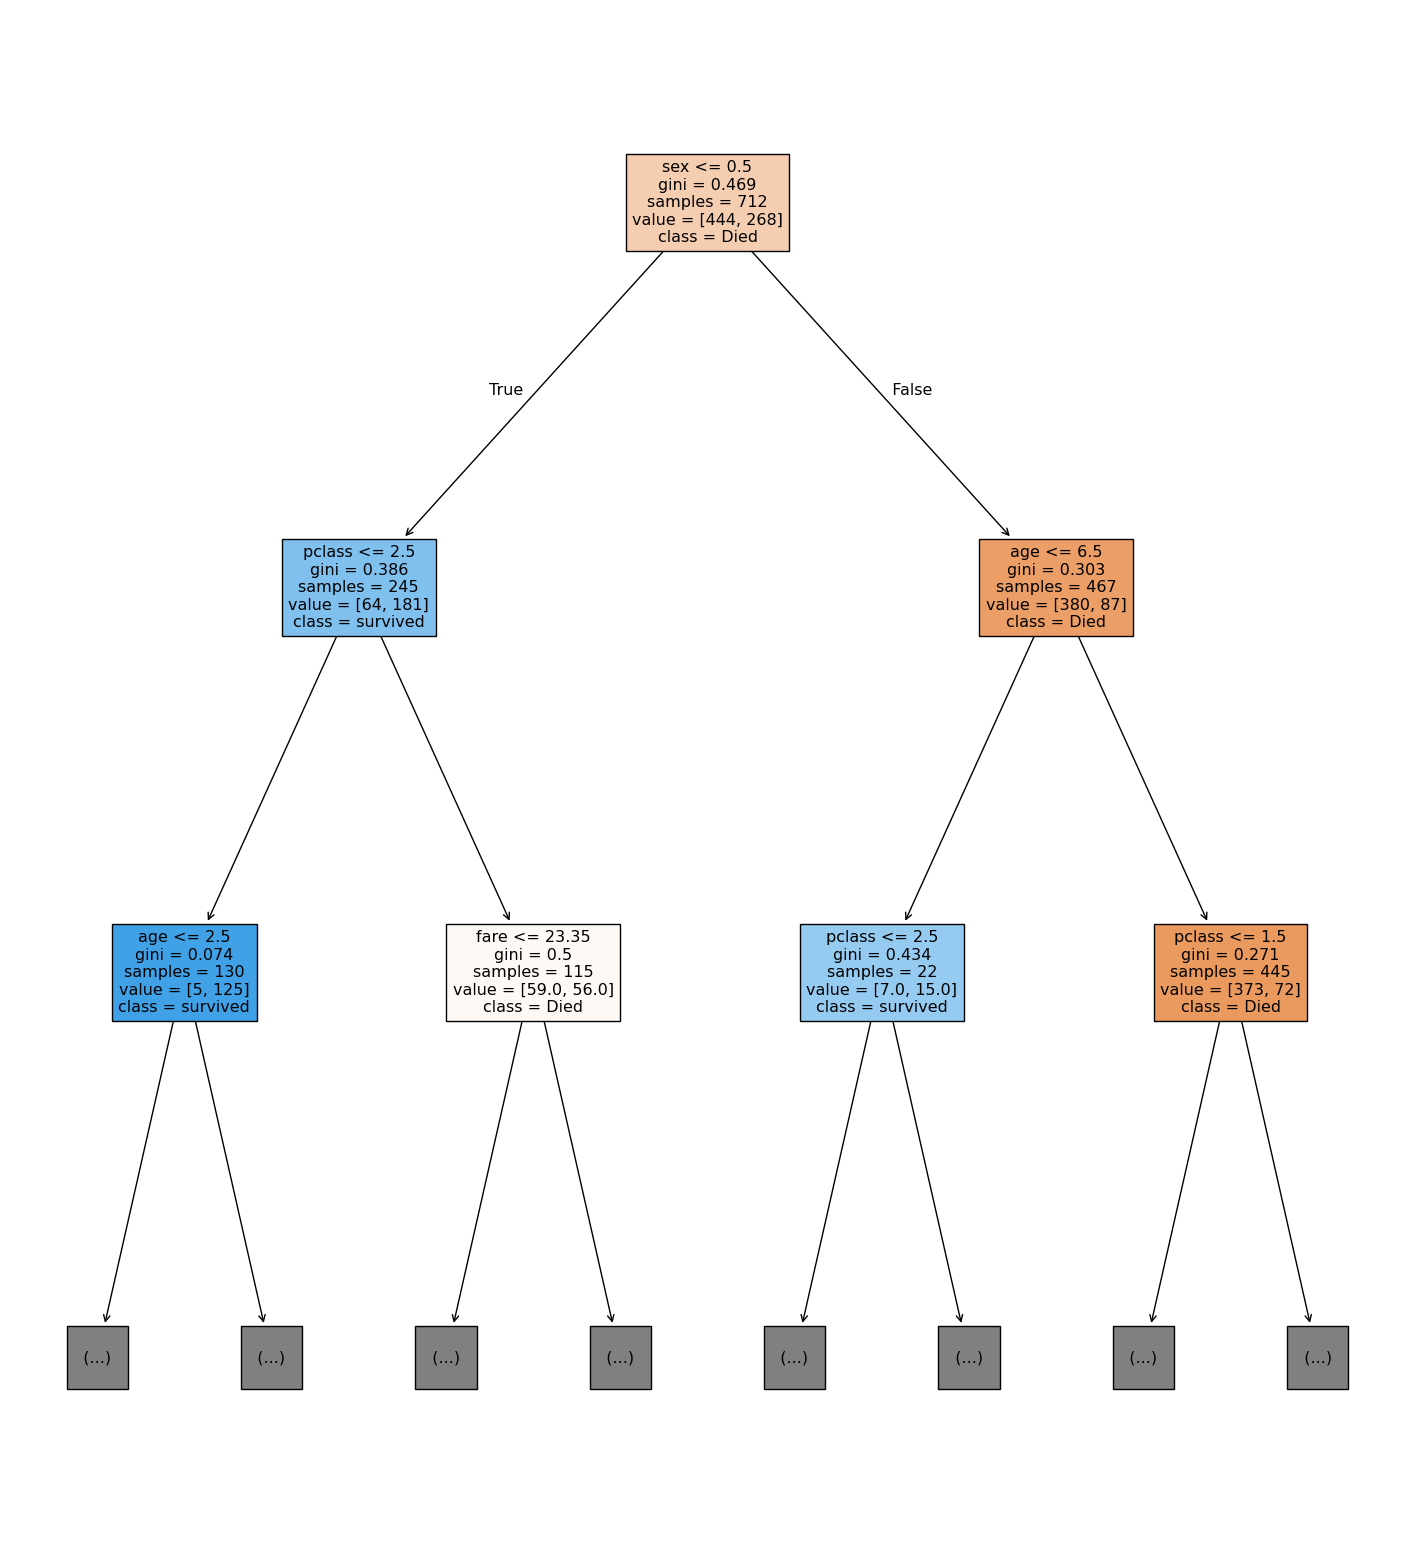

In [22]:
plt.figure(figsize=(18,20))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","survived"],
    filled=True,
     max_depth =2
)
plt.show()

## pre-pruning

In [26]:
max_depths = [2, 3, 4, 5, 6, 7, 8, 9, 10]
for dept in max_depths:
    model = DecisionTreeClassifier(max_depth=dept)
    model.fit(X_train, Y_train)
    acc = model.score(X_test,Y_test)
    print(f"dept={dept} acc is = {acc}")

dept=2 acc is = 0.7653631284916201
dept=3 acc is = 0.7988826815642458
dept=4 acc is = 0.7988826815642458
dept=5 acc is = 0.7988826815642458
dept=6 acc is = 0.8044692737430168
dept=7 acc is = 0.7932960893854749
dept=8 acc is = 0.7988826815642458
dept=9 acc is = 0.7877094972067039
dept=10 acc is = 0.7877094972067039


for sample split=5, accuracy=0.7988826815642458
for sample split=10, accuracy=0.7988826815642458


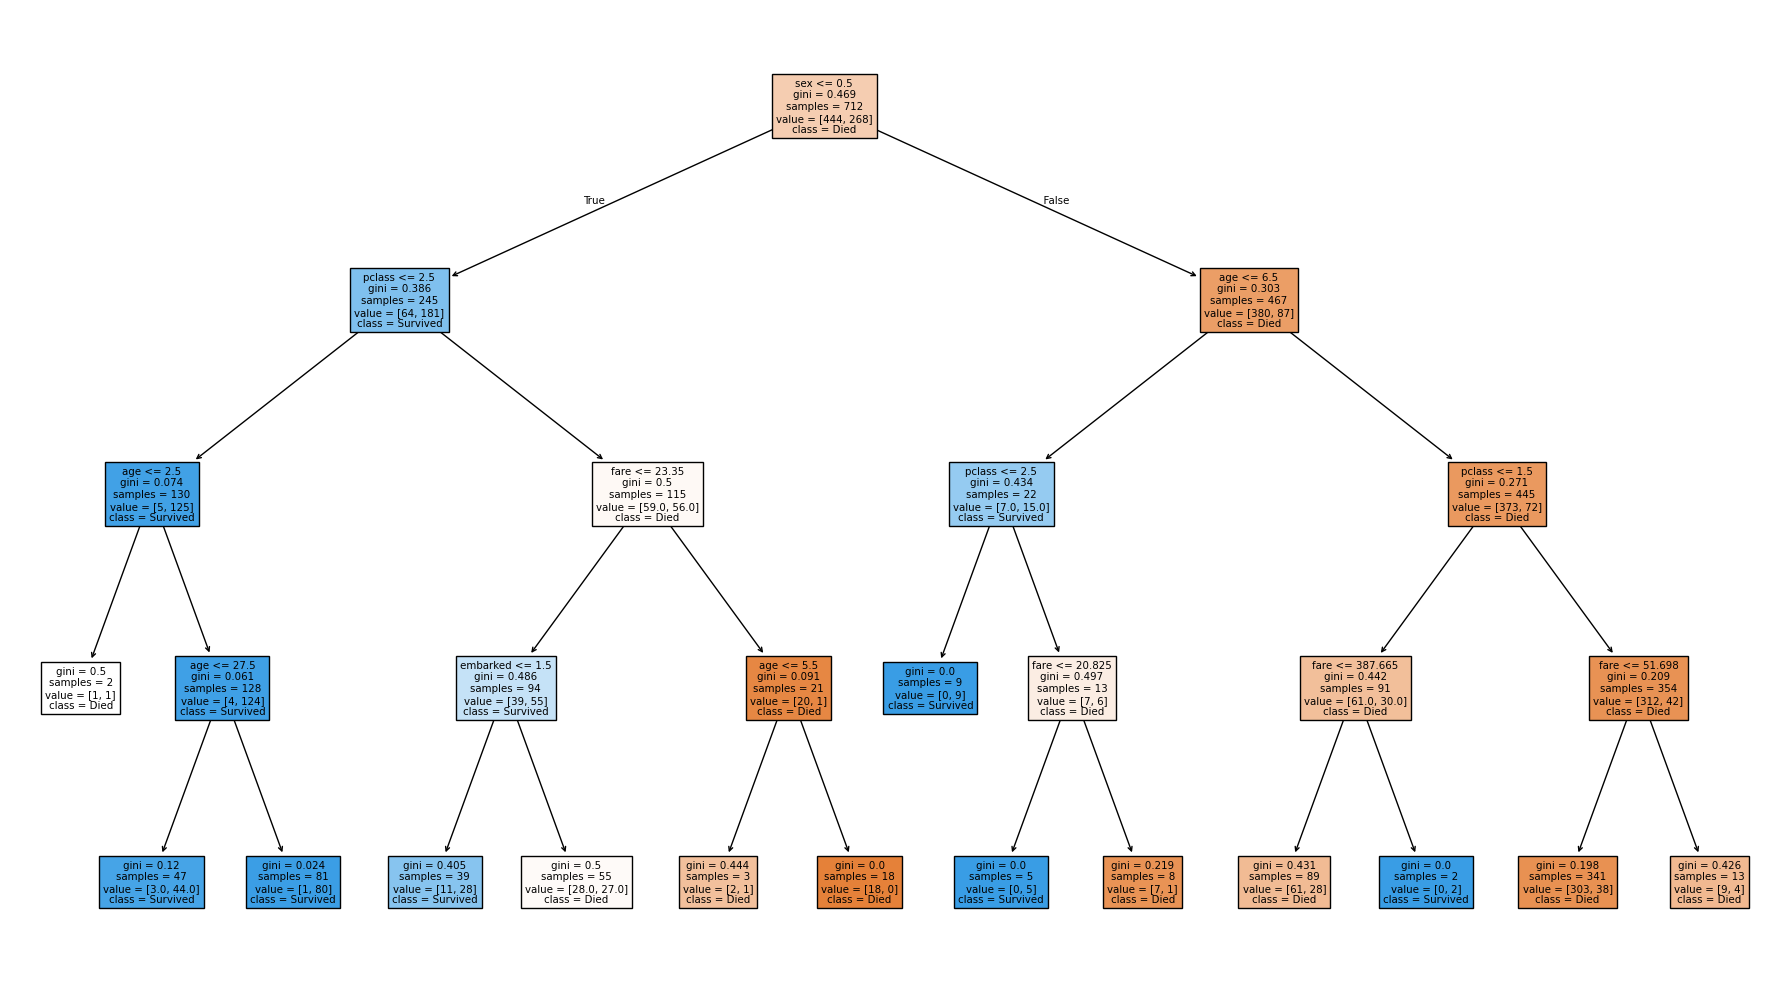

for sample split=15, accuracy=0.7988826815642458
for sample split=20, accuracy=0.7988826815642458
for sample split=25, accuracy=0.7932960893854749
for sample split=30, accuracy=0.7932960893854749


In [28]:
min_samples_splits = [5, 10, 15, 20, 25, 30]

for split in min_samples_splits:
    model = DecisionTreeClassifier(max_depth=4, min_samples_split=split)
    model.fit(X_train, Y_train)

    acc = model.score(X_test, Y_test)
    print(f"for sample split={split}, accuracy={acc}")

    if split==10:
        plt.figure(figsize=(18, 10))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["Died", "Survived"],
            filled=True
        )
        
        plt.tight_layout()
        plt.show()

# Decision Tree With Post pruning

In [42]:
full_tree= DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [46]:
path = full_tree.cost_complexity_pruning_path(X_train, Y_train)
ccp_alphas = path.ccp_alphas
ccp_alphas

array([0.00000000e+00, 0.00000000e+00, 6.68806849e-05, 1.45921494e-04,
       1.84428555e-04, 2.00642055e-04, 2.34082397e-04, 2.34082397e-04,
       3.51123596e-04, 4.68164794e-04, 4.68164794e-04, 5.61797753e-04,
       6.24219725e-04, 6.67991230e-04, 7.02247191e-04, 7.02247191e-04,
       8.19288390e-04, 8.19288390e-04, 8.32292967e-04, 8.42696629e-04,
       8.42696629e-04, 8.42696629e-04, 8.94231048e-04, 8.99610781e-04,
       9.24769963e-04, 9.36329588e-04, 9.36329588e-04, 9.36329588e-04,
       9.88347898e-04, 1.00253471e-03, 1.05337079e-03, 1.07400895e-03,
       1.08038029e-03, 1.11865144e-03, 1.12359551e-03, 1.12359551e-03,
       1.13139825e-03, 1.17041199e-03, 1.18841832e-03, 1.22566125e-03,
       1.22893258e-03, 1.22893258e-03, 1.24361593e-03, 1.24843945e-03,
       1.27565833e-03, 1.30996111e-03, 1.33761370e-03, 1.37044603e-03,
       1.46301498e-03, 1.47927070e-03, 1.51142557e-03, 1.54072312e-03,
       1.56675436e-03, 1.60434338e-03, 1.66892062e-03, 1.76144762e-03,
      

In [49]:
tree = []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(ccp_alpha=alpha)
    model.fit(X_train,Y_train)
    tree.append((model,alpha))
    

In [66]:
best_acc = 0
best_alpha = 0

for model,alpha in tree:
   acc =  model.score(X_test,Y_test)
   if acc > best_acc:
        best_acc = acc
        best_alpha = alpha
print(best_acc,best_alpha)

0.8379888268156425 0.0018675145079639476


# best model is 

In [67]:
final_best_model = DecisionTreeClassifier(ccp_alpha=best_alpha)
final_best_model.fit(X_train,Y_train)
acc = final_best_model.score(X_test,Y_tes)